## Autograd

In [70]:
import math

In [71]:
class Tensor:
    def __init__(self, data, label='', _children=()):
        self.data = data
        self.grad = 0.0
        self.label = label
        self._prev = set(_children)
        self._backward = lambda: None

    def __repr__(self):
        return (
            f"Tensor(data={self.data}, "
            f"grad={self.grad}, "
            f"label='{self.label}')"
        )

    def __add__(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)

        out = Tensor(
            self.data + other.data,
            _children=(self, other),
            label='+'
        )

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward

        return out

    def __radd__(self, other):
        return self + other

    def __neg__(self):
        out = Tensor(
            -self.data,
            _children=(self,),
            label='neg'
        )

        def _backward():
            self.grad += -out.grad

        out._backward = _backward

        return out

    def __sub__(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)

        return self + (-other)

    def __rsub__(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)

        return other - self

    def __mul__(self, other):
        if not isinstance(other, Tensor):
            other = Tensor(other)

        out = Tensor(
            self.data * other.data,
            _children=(self, other),
            label='*'
        )

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward

        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, power):
        out = Tensor(
            self.data ** power,
            _children=(self,),
            label=f'**{power}'
        )

        def _backward():
            self.grad += (
                power
                * self.data ** (power - 1)
                * out.grad
            )

        out._backward = _backward

        return out

    def relu(self):
        out = Tensor(
            max(0, self.data),
            _children=(self,),
            label='relu'
        )

        def _backward():
            self.grad += (out.data > 0) * out.grad

        out._backward = _backward

        return out

    def tanh(self):
        t = math.tanh(self.data)

        out = Tensor(
            t,
            _children=(self,),
            label='tanh'
        )

        def _backward():
            self.grad += (1 - t**2) * out.grad

        out._backward = _backward

        return out

    def sigmoid(self):
        x = self.data

        if x >= 0:
            s = 1 / (1 + math.exp(-x))
        else:
            exp_x = math.exp(x)
            s = exp_x / (1 + exp_x)

        out = Tensor(
            s,
            _children=(self,),
            label='sigmoid'
        )

        def _backward():
            self.grad += s * (1 - s) * out.grad

        out._backward = _backward

        return out

    def log(self):
        out = Tensor(
            math.log(self.data),
            _children=(self,),
            label='log'
        )

        def _backward():
            self.grad += (1 / self.data) * out.grad

        out._backward = _backward

        return out

    def backward(self):
        self.grad = 1.0

        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v._prev:
                    build_topo(child)

                topo.append(v)

        build_topo(self)

        for v in reversed(topo):
            v._backward()


### Neural network

In [72]:
import random

In [73]:
class Neuron:
    def __init__(self, nin, nonlin=True, activation=None):
        self.w = [Tensor(random.uniform(-1, 1), label=f'w{i}') for i in range(nin)]
        self.b = Tensor(0)
        self.nonlin = nonlin
        self.activation = activation

    def __call__(self, x):
        n = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        if self.activation == "sigmoid":
            return n.sigmoid()

        if self.nonlin:
            return n.relu()
        return n
    
    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, n_inputs, n_neurons, nonlin=True, activation=None):
        self.neurons = [Neuron(n_inputs, nonlin, activation) for _ in range(n_neurons)]

    def __call__(self, x):
        out = [neuron(x) for neuron in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = []

        for i in range(len(nouts)):
            if i < len(nouts) - 1:
                layer = Layer(sz[i], sz[i + 1], nonlin=True)
            else:
                layer = Layer(sz[i], sz[i + 1], nonlin=False, activation="sigmoid")
            self.layers.append(layer)

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


## Training

In [74]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [75]:
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X.shape, y.shape

((200, 2), (200,))

In [ ]:
model = MLP(2, [16, 16, 1])

learning_rate = 0.001

epochs = 100

losses = []

In [ ]:
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    predictions = []

    for x in X:
        inputs = [
            Tensor(x[0]),
            Tensor(x[1])
        ]

        pred = model(inputs)
        predictions.append(pred)

    loss = sum(
        -(
            Tensor(float(target)) * pred.log()
            +
            Tensor(1.0 - float(target)) * (1.0 - pred).log()
        )
        for pred, target in zip(predictions, y)
    )

    loss = loss * (1.0 / len(y))

    losses.append(loss.data)

    loss.backward()

    for p in model.parameters():
        p.data -= learning_rate * p.grad

    for p in model.parameters():
        p.grad = 0.0

    print(f"epoch={epoch}, loss={loss.data:.4f}")


Epoch 1/50
epoch=0, loss=0.4073
Epoch 2/50
epoch=1, loss=0.4070
Epoch 3/50
epoch=2, loss=0.4067
Epoch 4/50
epoch=3, loss=0.4064
Epoch 5/50
epoch=4, loss=0.4061
Epoch 6/50
epoch=5, loss=0.4058
Epoch 7/50
epoch=6, loss=0.4055
Epoch 8/50
epoch=7, loss=0.4052
Epoch 9/50
epoch=8, loss=0.4049
Epoch 10/50
epoch=9, loss=0.4046
Epoch 11/50
epoch=10, loss=0.4043
Epoch 12/50
epoch=11, loss=0.4040
Epoch 13/50
epoch=12, loss=0.4037
Epoch 14/50
epoch=13, loss=0.4034
Epoch 15/50
epoch=14, loss=0.4031
Epoch 16/50
epoch=15, loss=0.4028
Epoch 17/50
epoch=16, loss=0.4025
Epoch 18/50
epoch=17, loss=0.4023
Epoch 19/50
epoch=18, loss=0.4020
Epoch 20/50
epoch=19, loss=0.4017
Epoch 21/50
epoch=20, loss=0.4014
Epoch 22/50
epoch=21, loss=0.4012
Epoch 23/50
epoch=22, loss=0.4009
Epoch 24/50
epoch=23, loss=0.4006
Epoch 25/50
epoch=24, loss=0.4004
Epoch 26/50
epoch=25, loss=0.4001
Epoch 27/50
epoch=26, loss=0.3998
Epoch 28/50
epoch=27, loss=0.3996
Epoch 29/50
epoch=28, loss=0.3993
Epoch 30/50
epoch=29, loss=0.3991

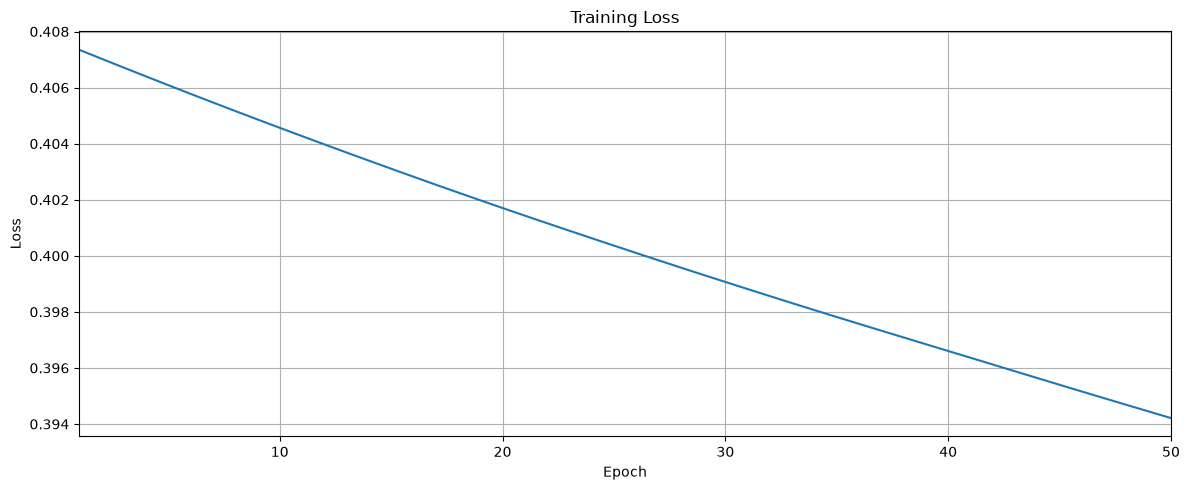

In [78]:
plt.figure(figsize=(12, 5))

epochs_x = range(1, len(losses) + 1)

plt.plot(epochs_x, losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.xlim(1, len(losses))
plt.grid(True)

plt.tight_layout()
plt.show()

In [79]:
new_x = [1.5, -0.2]

inputs = [
    Tensor(new_x[0]),
    Tensor(new_x[1])
]

pred = model(inputs)

print("Probability:", pred.data)

Probability: 0.7631585034285995
